<a href="https://colab.research.google.com/github/JoeJr09/Titanic---Machine-Learning-from-Disaster/blob/main/TitanicKaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# **Titanic - Machine Learning from Disaster**

Mais informações e instruções para fazer:
https://www.kaggle.com/competitions/titanic/data

Hipoteses a serem exploradas ou provadas

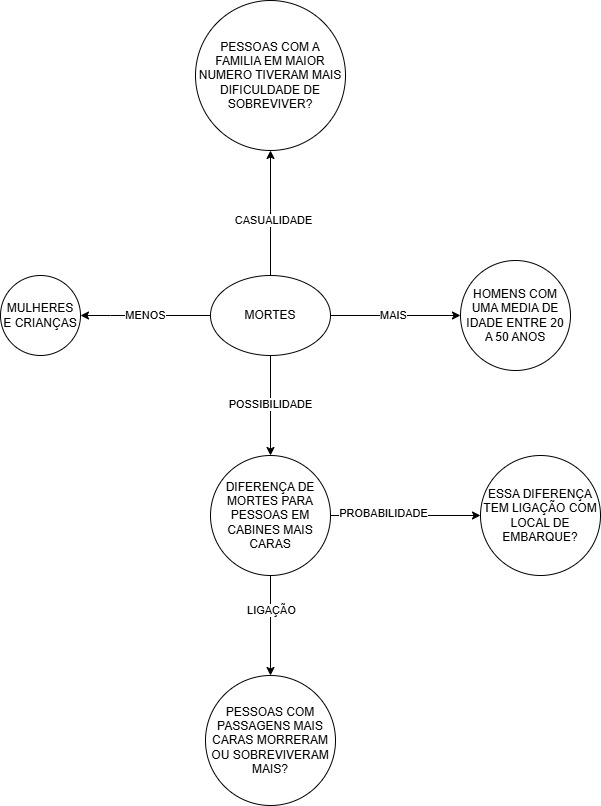

# Levantamento de dados e analise de hipoteses

## Carga e Análise Inicial dos Dados

In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/Titanic/train.csv')
test_df  = pd.read_csv('/content/Titanic/test.csv')

So importei a biblioteca panda e chamei como pd para facilitar o uso, e coloquei as duas tabelas em variáveis para guardalas: train_df e test_df

In [ ]:
train_df.head()

Mostras as 5 primeiras linhas do dataset

In [ ]:
train_df.info()

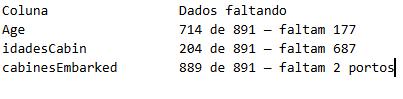



In [ ]:
train_df.describe()


```
Survived média = 0.38, so 38% sobreviveram
Age média = 29.7
Pclass média = 2.3
Fare max = 512
SibSp max = 8
```



### Análise de Sobrevivência por Gênero

## Análise de Hipóteses Detalhada

In [ ]:
import matplotlib.pyplot as plt

sobrevivencia_sexo = train_df.groupby('Sex') ['Survived']. mean()
print(sobrevivencia_sexo)

In [ ]:
sobrevivencia_sexo.plot(kind='bar', color=['salmon', 'steelblue'])

plt.title('Taxa de Sobrevivência por Gênero')
plt.ylabel('Taxa de Sobrevivência')
plt.xlabel('Gênero')
plt.xticks(rotation=0)
plt.show()



```
74% das mulheres sobreviveram
18% dos homens sobreviveram
```



In [ ]:
adultos = train_df[train_df['Age'] >= 18]

sobrevivencia_adultos = adultos.groupby('Sex')['Survived'].mean()
print(sobrevivencia_adultos)



```
Das mulheres presentes no navio, 74% sobreviveram.
Quando filtramos apenas mulheres adultas (+18 anos), essa taxa sobe para 77%.

Dos homens presentes no navio, apenas 18% sobreviveram.
Quando filtramos apenas homens adultos (+18 anos), essa taxa cai para 17%.
```



### Análise de Sobrevivência por Classe da Cabine

In [ ]:
sobrevivencia_classe = train_df.groupby('Pclass')['Survived'].mean()
print(sobrevivencia_classe)



```
Acima vimos que a descrepancia entre a taxas de sobrevivencia entre as cabines

Primeira Classe: 62% sobreviveram
Segunda Classe: 47% sobreviveram
Terceira Classe: 24% sobreviveram
```



### Análise de Sobrevivência por Porto de Embarque

In [ ]:
embarque_total = train_df.groupby('Embarked')['PassengerId'].count()
print(embarque_total)



```
Porto           Passageiros
Southampton (S)644 — 72% do total
Cherbourg   (C)168 — 19% do total
Queenstown  (Q)77 — 9% do total
```



In [ ]:
sobrevivencia_embarque = train_df.groupby('Embarked')['Survived'].mean()
print(sobrevivencia_embarque)



```
Porto           Passageiros     Taxa de sobrevivência
Cherbourg(C)        168                55%
Queenstown(Q)       77                 39%
Southampton(S)      644                33%
```



In [ ]:
classe_por_porto = train_df.groupby(['Embarked', 'Pclass'])['PassengerId'].count()
print(classe_por_porto)



```
Numero de tickts comprados em cada porto
Porto         1ªclasse  2ªclasse   3ªclasse

Cherbourg (C)   85      17          66
Queenstown(Q)   2        3          72
Southampton(S)  127     164         353
```



Cherbourg teve 55% de sobrevivência pois a maioria dos seus passageiros era de 1ª classe (85 pessoas) — a classe com maior taxa de sobrevivência.
Queenstown teve quase só passageiros de 3ª classe (72 de 77) mas mesmo assim sobreviveu mais que Southampton proporcionalmente.
Southampton embarcou o maior volume mas com maioria em 3ª classe, o que puxa a taxa de sobrevivência para baixo.

### Análise de Sobrevivência por Número de Familiares

In [ ]:
train_df['Familares'] = train_df['SibSp'] + train_df['Parch']

sobrevivencia_familia = train_df.groupby('Familares')['Survived'].mean()
print(sobrevivencia_familia)



```
Familiares           Taxa de sobrevivência
0 (viajando sozinho)          30%
1 familiar                    55%
2 familiares                  58%
3 familiares                  72%
4 familiares                  20%
5 familiares                  13%
6 familiares                  33%
7+ familiares                 0%

Sozinho → sobrevivência baixa (30%)
Família pequena (1-3) → sobrevivência alta, chegando a 72%
Família grande (4+) → sobrevivência despenca, chegando a 0%
```



### Análise de Sobrevivência por Idade Média e Gênero

In [ ]:
idade_sobrevivencia = train_df.groupby(['Sex', 'Survived'])['Age'].mean()
print(idade_sobrevivencia)



```
Media de 25 anos pras mulheres que morreram e 28 anos pras que sobreviveram

Media de 31 anos pros homens que morreram e 27 anos pros que sobreviveram
```



## Visualização Consolidada das Análises de Sobrevivência

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análise de Sobrevivência - Titanic', fontsize=16, fontweight='bold')

# Gráfico 1 - Gênero
sobrevivencia_sexo = train_df.groupby('Sex')['Survived'].mean()
axes[0,0].bar(sobrevivencia_sexo.index, sobrevivencia_sexo.values, color=['salmon', 'steelblue'])
axes[0,0].set_title('Por Gênero')
axes[0,0].set_ylabel('Taxa de Sobrevivência')

# Gráfico 2 - Classe
sobrevivencia_classe = train_df.groupby('Pclass')['Survived'].mean()
axes[0,1].bar(['1ª Classe', '2ª Classe', '3ª Classe'], sobrevivencia_classe.values, color=['gold', 'silver', 'peru'])
axes[0,1].set_title('Por Classe da Cabine')

# Gráfico 3 - Porto de embarque
sobrevivencia_embarque = train_df.groupby('Embarked')['Survived'].mean()
axes[0,2].bar(sobrevivencia_embarque.index, sobrevivencia_embarque.values, color=['mediumpurple', 'mediumseagreen', 'tomato'])
axes[0,2].set_title('Por Porto de Embarque')

# Gráfico 4 - Familiares
sobrevivencia_familia = train_df.groupby('Familares')['Survived'].mean()
axes[1,0].bar(sobrevivencia_familia.index, sobrevivencia_familia.values, color='cornflowerblue')
axes[1,0].set_title('Por Número de Familiares')
axes[1,0].set_xlabel('Nº de Familiares')
axes[1,0].set_ylabel('Taxa de Sobrevivência')

# Gráfico 5 - Idade média por gênero e sobrevivência
categorias = ['Mulher\nNão sobreviveu', 'Mulher\nSobreviveu', 'Homem\nNão sobreviveu', 'Homem\nSobreviveu']
idades = [25.04, 28.84, 31.61, 27.27]
cores = ['salmon', 'salmon', 'steelblue', 'steelblue']
axes[1,1].bar(categorias, idades, color=cores)
axes[1,1].set_title('Idade Média por Gênero e Sobrevivência')
axes[1,1].set_ylabel('Idade Média')

# Gráfico 6 - Classe por porto
classe_porto = train_df.groupby(['Embarked', 'Pclass'])['PassengerId'].count().unstack()
classe_porto.plot(kind='bar', ax=axes[1,2], color=['gold', 'silver', 'peru'])
axes[1,2].set_title('Classe por Porto de Embarque')
axes[1,2].set_xlabel('Porto')
axes[1,2].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'], rotation=0)
axes[1,2].legend(['1ª Classe', '2ª Classe', '3ª Classe'])

plt.tight_layout()
plt.show()

## Modelagem Preditiva

Após essas análises, podemos fazer o código em Python usando a biblioteca sklearn, utilizando primeiro a árvore de decisão e logo após a floresta aleatória (Ou RandomForest).



### Construção e Previsão dos Modelos (Sem Validação Interna)

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


caminho_arquivo_train = '/content/Titanic/train.csv'
caminho_arquivo_test = '/content/Titanic/test.csv'

train_df = pd.read_csv(caminho_arquivo_train)
test_df = pd.read_csv(caminho_arquivo_test)


#preenche as linhas vazias com as informações que mais aparecem
train_df['Embarked'] = train_df['Embarked'].fillna('S')
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['Embarked'] = test_df['Embarked'].fillna('S')

#por convensão, y é utilizado como o "Alvo", a variável que é tentado a adivinhação
y = train_df.Survived

#aqui se coloca todas as colunas da tabela CSV que serão "estudadas"
#nesse caso inicial, colocarei todas as de test, exceto o ID do passageiro, Name, Ticket e Cabin
features = ['Pclass', 'Sex', 'SibSp',
            'Parch', 'Fare', 'Embarked']


#se o y é o alvo, o X é o treinamento
X_train = train_df[features].copy()
X_test = test_df[features].copy()



#temos que converter os parâmetros que não são números para números
X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_train['Embarked'] = X_train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

X_test['Sex'] = X_test['Sex'].map({'male': 0, 'female': 1})
X_test['Embarked'] = X_test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


#criar o modelo
modelo_arvore = DecisionTreeClassifier(random_state=1)


#fit no modelo (passar o treinamento, alvo)
modelo_arvore.fit(X_train, y)

#agora ele prevê o resultado
modelo_arvore.predict(X_test.head())
print(f"Resultado com árvore de decisão SEM quantidade de galhos especificada (Só as 5 primeiras): {modelo_arvore.predict(X_test.head())}")

#esse de cima vai sem definir a quantidade de galhos que a máquina usa, o código abaixo delimita o máximo de galhos até chegar nas folhas

#-------------------------------------------------------------↓↓↓↓ aqui fica onde definir a quantidade
modelo_arvore_max_leaf_nodes = DecisionTreeClassifier(max_leaf_nodes=100, random_state=1)
modelo_arvore_max_leaf_nodes.fit(X_train, y)
modelo_arvore_max_leaf_nodes.predict(X_test.head())
print(f"Resultado com árvore de decisão COM quantidade de galhos especificada: {modelo_arvore_max_leaf_nodes.predict(X_test.head())}")





#agora faremos a versão com o modelo de floresta aleatória
modelo_floresta = RandomForestClassifier(random_state=1)
modelo_floresta.fit(X_train, y)
modelo_floresta.predict(X_test.head())
print(f"Resultado com floresta aleatória (Só as 5 primeiras): {modelo_floresta.predict(X_test.head())}")



#geraremos 3 arquivos para verificar a qualidade da predição = decisiontree.csv, decisiontreemax.csv e randomforest.csv
# O formato exigido é: PassengerId, Survived
output = pd.DataFrame({
    'PassengerId': test_df.PassengerId,
    'Survived': modelo_arvore.predict(X_test)
})

# Salvar como CSV
output.to_csv('decisiontree.csv', index=False)

print("Arquivo 'decisiontree.csv' criado com sucesso!")

#-----------------------
output2 = pd.DataFrame({
    'PassengerId': test_df.PassengerId,
    'Survived': modelo_arvore_max_leaf_nodes.predict(X_test)
})

# Salvar como CSV
output2.to_csv('decisiontreemax.csv', index=False)

print("Arquivo 'decisiontreemax.csv' criado com sucesso!")

#---------------------------
output3 = pd.DataFrame({
    'PassengerId': test_df.PassengerId,
    'Survived': modelo_floresta.predict(X_test)
})

# Salvar como CSV
output3.to_csv('randomforest.csv', index=False)

print("Arquivo 'randomforest.csv' criado com sucesso!")

# Resultado da Kaggle:

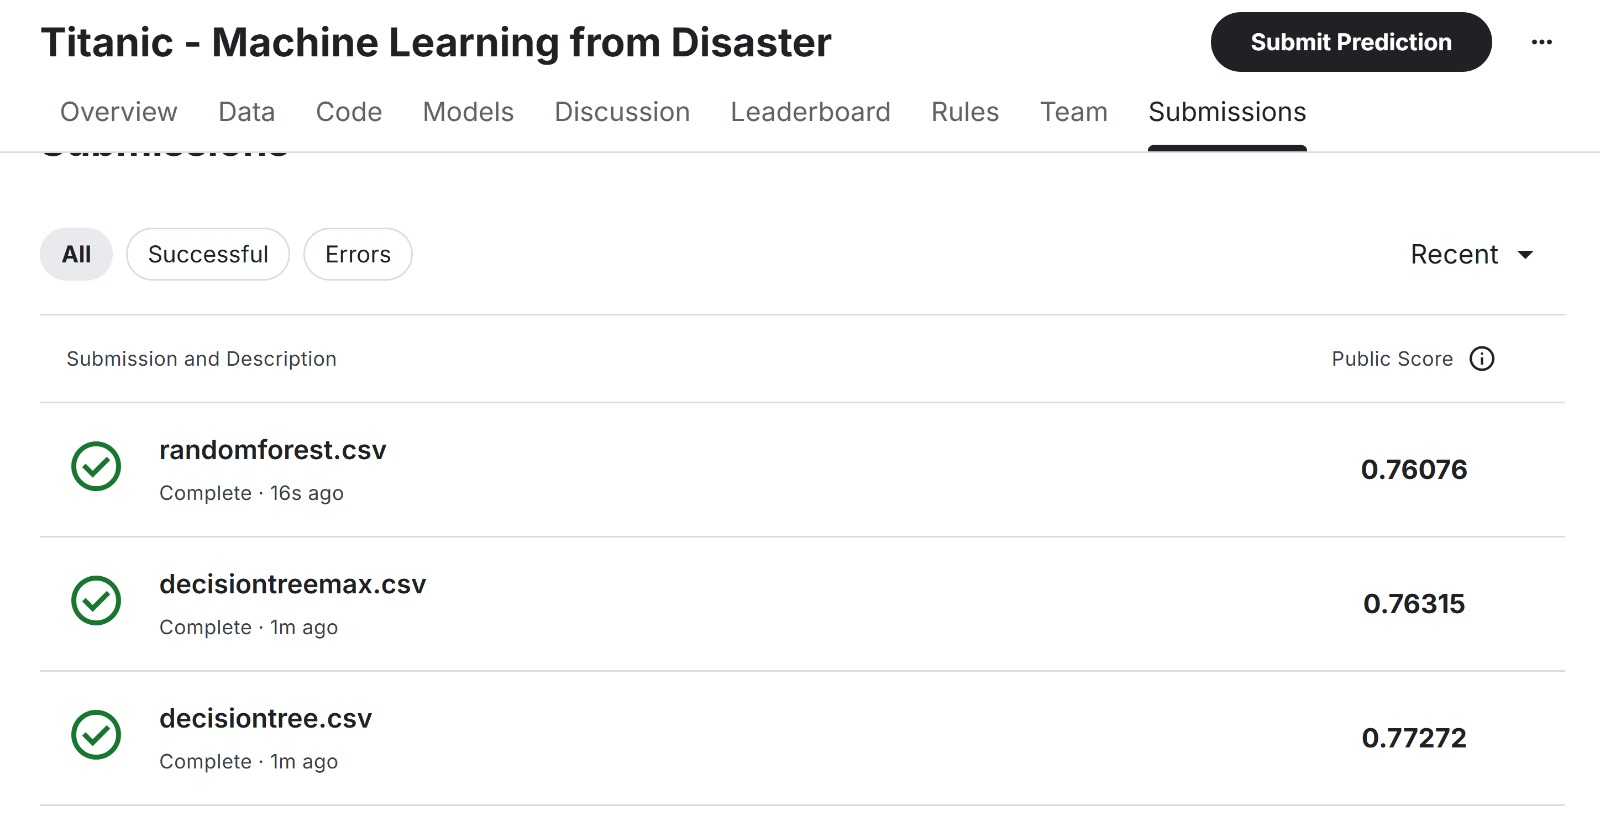

### Validação Interna do Modelo (Usando Holdout)

Fazendo agora a nossa própria validação e depois comparando com o resultado da Kaggle. Vamos fazer através do método holdout, que consiste em pegar uma parte dos dados e dividir entre TESTE e VALIDAÇÃO, fazendo com que nós possamos avaliar a precisão da máquina, pois assim ela não terá acesso a todos os dados.

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


caminho_arquivo_train = '/content/Titanic/train.csv'

train_df = pd.read_csv(caminho_arquivo_train)


#preenche as linhas vazias com as informações que mais aparecem
train_df['Embarked'] = train_df['Embarked'].fillna('S')
train_df['Fare'] = train_df['Fare'].fillna(train_df['Fare'].median())
train_df['Embarked'] = train_df['Embarked'].fillna('S')

#por convensão, y é utilizado como o "Alvo", a variável que é tentado a adivinhação
y = train_df.Survived

#aqui se coloca todas as colunas da tabela CSV que serão "estudadas"
#nesse caso inicial, colocarei todas as de test, exceto o ID do passageiro, Name, Ticket e Cabin
features = ['Pclass', 'Sex', 'SibSp',
            'Parch', 'Fare', 'Embarked']


#se o y é o alvo, o X é o treinamento
X_train = train_df[features].copy()


#temos que converter os parâmetros que não são números para números
X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_train['Embarked'] = X_train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

#fazemos a validação da qualidade através daqui
train_X, val_X, train_y, val_y = train_test_split(X_train, y, test_size=0.2 , random_state=1)
                                                        #-------^^^^^^^^ aqui definimos o tanto que será repartido (nesse caso, 20% dos dados serão escondidos para validação)

#criar o modelo
modelo_arvore = DecisionTreeClassifier(random_state=1)
#fit no modelo (passar o treinamento, alvo)
modelo_arvore.fit(train_X, train_y)
#agora ele prevê o resultado
pred_arvore = modelo_arvore.predict(val_X)
print(f"Resultado com árvore de decisão SEM quantidade de galhos especificada: {accuracy_score(val_y, pred_arvore):.4f}")

#esse de cima vai sem definir a quantidade de galhos que a máquina usa, o código abaixo delimita o máximo de galhos até chegar nas folhas
#-------------------------------------------------------------↓↓↓↓ aqui fica onde definir a quantidade
modelo_arvore_max_leaf_nodes = DecisionTreeClassifier(max_leaf_nodes=100, random_state=1)
modelo_arvore_max_leaf_nodes.fit(train_X, train_y)
pred_arvore_max_node = modelo_arvore_max_leaf_nodes.predict(val_X)
print(f"Resultado com árvore de decisão COM quantidade de galhos especificada: {accuracy_score(val_y, pred_arvore_max_node):.4f}")




#agora faremos a versão com o modelo de floresta aleatória
modelo_floresta = RandomForestClassifier(random_state=1)
modelo_floresta.fit(train_X, train_y)
pred_floresta = modelo_floresta.predict(val_X)
print(f"Resultado com floresta aleatória: {accuracy_score(val_y, pred_floresta):.4f}")